In [2]:
import pandas as pd

df = pd.read_csv("medical_appointment_no_shows.csv")
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [3]:
df.info()
df["No-show"].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB


No-show
No     88208
Yes    22319
Name: count, dtype: int64

In [4]:
## Exploratory Data Analysis (EDA)
# We analyze class distribution and basic relationships between features and the target.

In [5]:
df["No-show"].value_counts(normalize=True)

No-show
No     0.798067
Yes    0.201933
Name: proportion, dtype: float64

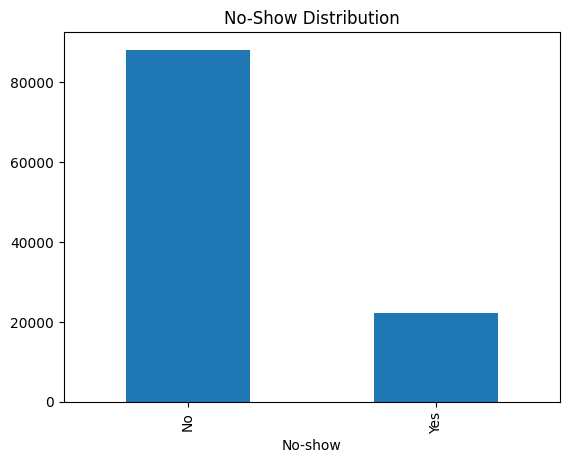

In [6]:
import matplotlib.pyplot as plt

df["No-show"].value_counts().plot(kind="bar", title="No-Show Distribution")
plt.show()

In [7]:
# Relationship with SMS reminders
pd.crosstab(df["SMS_received"], df["No-show"], normalize="index")

No-show,No,Yes
SMS_received,,
0,0.832967,0.167033
1,0.724255,0.275745


In [8]:
## Data Preprocessing & Feature Engineering
# We clean the dataset, engineer useful features, and prepare it for model training.

In [9]:
# Drop IDs
df = df.drop(columns=["PatientId", "AppointmentID"], errors="ignore")

In [10]:
# Convert to datetime
df["ScheduledDay"] = pd.to_datetime(df["ScheduledDay"])
df["AppointmentDay"] = pd.to_datetime(df["AppointmentDay"])

In [11]:
# New Column: Waiting Days
df["WaitingDays"] = (df["AppointmentDay"] - df["ScheduledDay"]).dt.days
df["WaitingDays"] = df["WaitingDays"].clip(lower=0)

In [12]:
# Target encoding
y = df["No-show"].map({"Yes": 1, "No": 0})
X = df.drop(columns=["No-show", "ScheduledDay", "AppointmentDay"])

In [13]:
# Train-Test Split + Preprocessing Pipeline

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [15]:
categorical_cols = X.select_dtypes(include=["object"]).columns
numerical_cols = X.select_dtypes(exclude=["object"]).columns
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ]
)

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

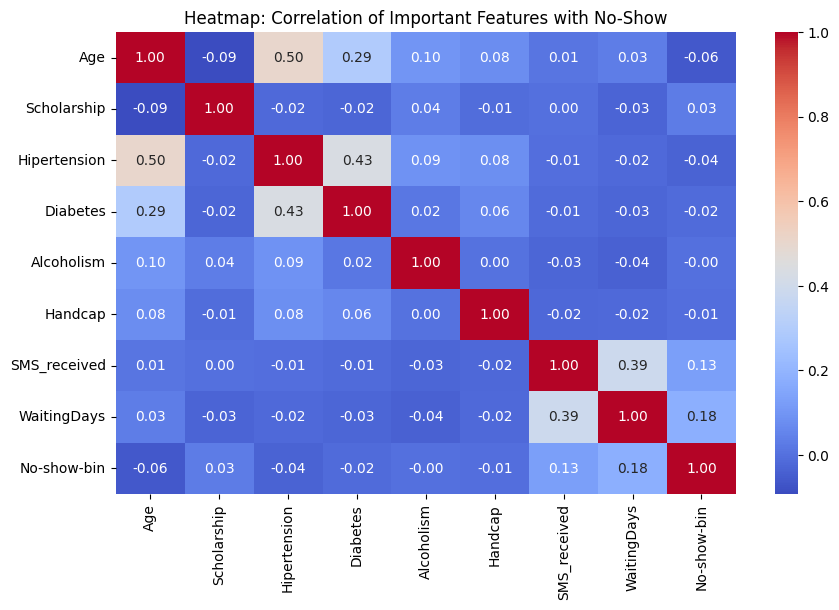

In [17]:
#HEAT MAP: IMPORTANT FEATURES

import seaborn as sns
import matplotlib.pyplot as plt

# Prepare numeric-only dataframe (encode target)
df_eda = df.copy()
df_eda['No-show-bin'] = df_eda['No-show'].map({'No': 0, 'Yes': 1})

numeric_cols = ['Age', 'Scholarship', 'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received', 'WaitingDays', 'No-show-bin']

corr = df_eda[numeric_cols].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Heatmap: Correlation of Important Features with No-Show")
plt.show()

In [18]:
## Model 1: Logistic Regression

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

In [20]:
log_reg_model = Pipeline(steps=[("preprocessor", preprocessor), ("classifier", LogisticRegression(max_iter=1000))])
log_reg_model.fit(X_train, y_train)
y_pred_log_reg = log_reg_model.predict(X_test)

In [21]:
print("Logistic Regression Results")
print(confusion_matrix(y_test, y_pred_log_reg))
print(classification_report(y_test, y_pred_log_reg))

Logistic Regression Results
[[17529   113]
 [ 4393    71]]
              precision    recall  f1-score   support

           0       0.80      0.99      0.89     17642
           1       0.39      0.02      0.03      4464

    accuracy                           0.80     22106
   macro avg       0.59      0.50      0.46     22106
weighted avg       0.72      0.80      0.71     22106



In [22]:
## Model 2: Decision Tree

In [23]:
from sklearn.tree import DecisionTreeClassifier

In [24]:
tree_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("clf", DecisionTreeClassifier(max_depth=5, random_state=42)) #other hyperparameters can be tuned as well.

    #find best values for max_depth, min_samples_split, min_samples_leaf using GridSearchCV or RandomizedSearchCV
])

tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)


print("Decision Tree Results")
print(confusion_matrix(y_test, y_pred_tree))
print(classification_report(y_test, y_pred_tree))

Decision Tree Results
[[17618    24]
 [ 4437    27]]
              precision    recall  f1-score   support

           0       0.80      1.00      0.89     17642
           1       0.53      0.01      0.01      4464

    accuracy                           0.80     22106
   macro avg       0.66      0.50      0.45     22106
weighted avg       0.74      0.80      0.71     22106



In [25]:
import joblib

joblib.dump(log_reg_model, "model.joblib")

['model.joblib']

In [26]:
#comparsion of classification reports of both models

from sklearn.metrics import classification_report

# Predictions
y_pred_lr = log_reg_model.predict(X_test)
y_pred_tree = tree_model.predict(X_test)  # or best_tree_model if tuned

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr))

print("=== Decision Tree ===")
print(classification_report(y_test, y_pred_tree))

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.80      0.99      0.89     17642
           1       0.39      0.02      0.03      4464

    accuracy                           0.80     22106
   macro avg       0.59      0.50      0.46     22106
weighted avg       0.72      0.80      0.71     22106

=== Decision Tree ===
              precision    recall  f1-score   support

           0       0.80      1.00      0.89     17642
           1       0.53      0.01      0.01      4464

    accuracy                           0.80     22106
   macro avg       0.66      0.50      0.45     22106
weighted avg       0.74      0.80      0.71     22106



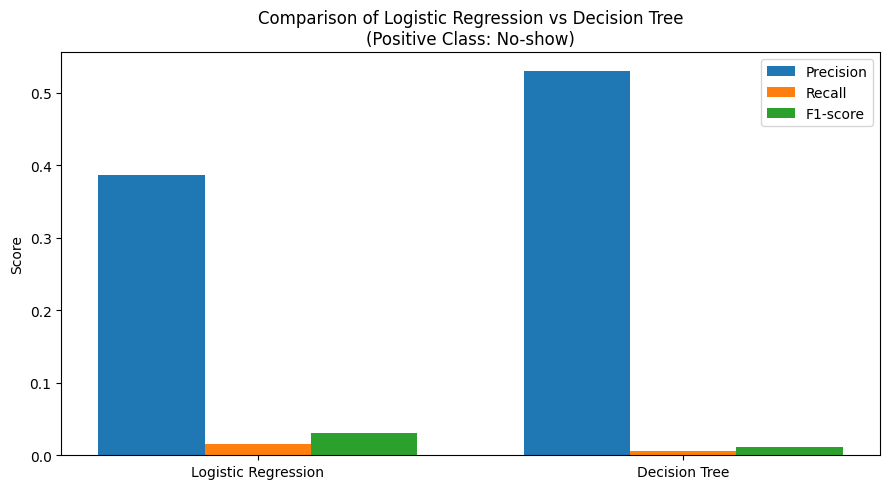

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

# Extract classification reports as dictionaries
report_lr = classification_report(y_test, y_pred_lr, output_dict=True)
report_tree = classification_report(y_test, y_pred_tree, output_dict=True)

# Extract positive class (1 = No-show) metrics
precision = [
    report_lr["1"]["precision"],
    report_tree["1"]["precision"]
]

recall = [
    report_lr["1"]["recall"],
    report_tree["1"]["recall"]
]

f1 = [
    report_lr["1"]["f1-score"],
    report_tree["1"]["f1-score"]
]

labels = ["Logistic Regression", "Decision Tree"]
x = np.arange(len(labels))
width = 0.25

plt.figure(figsize=(9,5))

plt.bar(x - width, precision, width, label="Precision")
plt.bar(x, recall, width, label="Recall")
plt.bar(x + width, f1, width, label="F1-score")

plt.xticks(x, labels)
plt.ylabel("Score")
plt.title("Comparison of Logistic Regression vs Decision Tree\n(Positive Class: No-show)")
plt.legend()

plt.tight_layout()
plt.show()